## Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [ ]:
pip install geoip2

In [ ]:
import geoip2.database

Download IP address database to get the  country out of the IP address

In [ ]:
!wget -O GeoLite2-Country.mmdb "https://git.io/GeoLite2-Country.mmdb"
if os.path.exists('GeoLite2-Country.mmdb'):
    print('Database file downloaded successfully.')

--2026-05-31 09:20:44--  https://git.io/GeoLite2-Country.mmdb
Resolving git.io (git.io)... 140.82.114.22
Connecting to git.io (git.io)|140.82.114.22|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/P3TERX/GeoLite.mmdb/releases/latest/download/GeoLite2-Country.mmdb [following]
--2026-05-31 09:20:44--  https://github.com/P3TERX/GeoLite.mmdb/releases/latest/download/GeoLite2-Country.mmdb
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/P3TERX/GeoLite.mmdb/releases/download/2026.05.31/GeoLite2-Country.mmdb [following]
--2026-05-31 09:20:44--  https://github.com/P3TERX/GeoLite.mmdb/releases/download/2026.05.31/GeoLite2-Country.mmdb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/gi

In [ ]:
try:
    reader = geoip2.database.Reader('GeoLite2-Country.mmdb')
    print("Local database loaded successfully.")
except Exception as e:
    print(f"Error loading database: {e}")
    reader = None

Local database loaded successfully.


In [ ]:
df = pd.read_csv("transactions.csv")

In [ ]:
df.head(5)

,transaction_id,timestamp,card_id,amount,merchant_name,merchant_category,channel,cardholder_country,merchant_country,device_id,ip_address
0,tx_000784,2026-04-25T00:27:09,card_042,18.38,Amazon.ca,online_retail,online,US,CA,dev_33892b01,172.58.159.61
1,tx_000081,2026-04-25T00:32:37,card_004,160.55,Schwartz's,restaurant,in_person,CA,CA,NaN,NaN
2,tx_000389,2026-04-25T01:39:26,card_020,57.12,Chipotle,restaurant,in_person,US,US,NaN,NaN
3,tx_000779,2026-04-25T02:38:38,card_041,15.86,Videotron,utilities,online,CA,CA,dev_614ef198,142.112.31.70
4,tx_000256,2026-04-25T04:26:31,card_013,52.73,Shopify Merchant 2,online_retail,online,CA,CA,dev_e5c2222f,24.114.1.85


## Feature Engineering

Find the country of the device's ip address

In [ ]:
def get_country(ip):
    if pd.isna(ip):
        return None
    try:
        response = reader.country(ip)
        return response.country.iso_code
    except:
        return None

df['ip_country'] = df['ip_address'].apply(get_country)

Check if the card holder's country is the same as the merchant country/ip address country

In [ ]:
# Flag mismatches between merchant and cardholder countries
df['country_mismatch'] = df['merchant_country'] != df['cardholder_country']

# Flag mismatches between IP country and cardholder country
# We check this only if ip_country is not None
def check_ip_mismatch(row):
    if pd.isna(row['ip_country']):
        return False
    return row['ip_country'] != row['cardholder_country']

df['ip_mismatch'] = df.apply(check_ip_mismatch, axis=1)

print(f"Total country mismatches found: {df['country_mismatch'].sum()}")
print(f"Total IP country mismatches found: {df['ip_mismatch'].sum()}")
display(df[['transaction_id', 'cardholder_country', 'merchant_country', 'ip_country', 'country_mismatch', 'ip_mismatch']].head())

Total country mismatches found: 262
Total IP country mismatches found: 63


,transaction_id,cardholder_country,merchant_country,ip_country,country_mismatch,ip_mismatch
0,tx_000784,US,CA,US,True,False
1,tx_000081,CA,CA,None,False,False
2,tx_000389,US,US,None,False,False
3,tx_000779,CA,CA,CA,False,False
4,tx_000256,CA,CA,CA,False,False


Check if some online transactions dont have an ip

In [ ]:
# Filter for online transactions with missing IP addresses
online_no_ip = df[(df['channel'] == 'online') & (df['ip_address'].isna())]

print(f"Number of online transactions without an IP address: {len(online_no_ip)}")

if not online_no_ip.empty:
    display(online_no_ip.head())
else:
    print("All online transactions have an associated IP address.")

Number of online transactions without an IP address: 0
All online transactions have an associated IP address.


Calculate the time since the last transaction for each card. Identify the first transaction for each user and filled the initial time gap with the median value of all gaps in the dataset.



In [ ]:
# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by card_id and timestamp to calculate gaps correctly
df = df.sort_values(['card_id', 'timestamp'])

# Calculate time since last transaction (in seconds)
df['time_since_last_transaction'] = df.groupby('card_id')['timestamp'].diff().dt.total_seconds()

# Identify first transactions
df['is_first_transaction'] = df['time_since_last_transaction'].isna()

# Calculate the median gap across the entire dataset
median_gap = df['time_since_last_transaction'].median()

# Fill the first transaction gaps with the median gap
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(median_gap)

Identify any transaction where the IP address used has also been linked to a different card in the dataset.

In [ ]:
# Calculate the number of unique cards per IP address
ip_card_counts = df.groupby('ip_address')['card_id'].nunique()

# Map these counts back to the original dataframe
df['unique_cards_on_ip'] = df['ip_address'].map(ip_card_counts)

# Flag if a transaction is made by an IP used by different cards
# We check if unique_cards_on_ip > 1 and ensure the IP is not null
df['ip_shared_with_multiple_cards'] = (df['unique_cards_on_ip'] > 1) & (df['ip_address'].notna())

# Display summary and examples of shared IP usage
print(f"Transactions linked to shared IPs: {df['ip_shared_with_multiple_cards'].sum()}")
display(df[df['ip_shared_with_multiple_cards'] == True][['transaction_id', 'card_id', 'ip_address', 'unique_cards_on_ip']].sort_values('ip_address').head(10))

Transactions linked to shared IPs: 2


,transaction_id,card_id,ip_address,unique_cards_on_ip
933,tx_000290,card_015,99.225.114.61,2.0
352,tx_000882,card_047,99.225.114.61,2.0


Calculate the number of unique cards per device ID

In [ ]:
# Calculate the number of unique cards per device ID
device_card_counts = df.groupby('device_id')['card_id'].nunique()

# Map these counts back to the original dataframe
df['unique_cards_on_device'] = df['device_id'].map(device_card_counts)

# Flag if a transaction is made by a device used by different cards
# We check if unique_cards_on_device > 1 and ensure the device_id is not null
df['device_shared_with_multiple_cards'] = (df['unique_cards_on_device'] > 1) & (df['device_id'].notna())

# Display summary and examples of shared device usage
print(f"Transactions linked to shared devices: {df['device_shared_with_multiple_cards'].sum()}")
display(df[df['device_shared_with_multiple_cards'] == True][['transaction_id', 'card_id', 'device_id', 'unique_cards_on_device']].sort_values('device_id').head(10))

Transactions linked to shared devices: 0


,transaction_id,card_id,device_id,unique_cards_on_device


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

def get_rolling_unique_ips_per_card(group, window_str):
    # Ensure group is sorted by time
    group = group.sort_values('timestamp')
    results = []
    window_td = pd.Timedelta(window_str)

    for current_time in group['timestamp']:
        start_time = current_time - window_td
        # Filter IPs within the current rolling window for this specific card group
        mask = (group['timestamp'] > start_time) & (group['timestamp'] <= current_time)
        unique_count = group.loc[mask, 'ip_address'].nunique()
        results.append(unique_count)
    return pd.Series(results, index=group.index)

print("Calculating rolling unique IP counts per card...")

# Defining the windows to calculate
windows = {'30min': 'card_unique_ips_30min', '60min': 'card_unique_ips_60min', '12h': 'card_unique_ips_12hr', '24h': 'card_unique_ips_1day'}

for window_str, col_name in windows.items():
    # Group by card_id and apply the fixed helper function with include_groups=False
    df[col_name] = df.groupby('card_id', group_keys=False).apply(lambda x: get_rolling_unique_ips_per_card(x, window_str), include_groups=False)

# Filter to show cards that have multiple IPs in a 24-hour window
card_features = list(windows.values())
display(df[df['card_unique_ips_1day'] > 1][['card_id', 'timestamp', 'ip_address'] + card_features].head(10))

Calculating rolling unique IP counts per card...


,card_id,timestamp,ip_address,card_unique_ips_30min,card_unique_ips_60min,card_unique_ips_12hr,card_unique_ips_1day
367,card_000,2026-05-06 17:13:00,189.144.34.189,1,1,1,2
514,card_001,2026-05-11 16:33:53,99.225.247.252,1,1,1,2
701,card_001,2026-05-16 15:53:05,99.225.135.151,1,1,2,2
918,card_001,2026-05-22 15:59:57,142.112.59.148,1,1,2,2
938,card_001,2026-05-23 07:45:13,99.225.213.186,1,1,1,3
959,card_001,2026-05-23 23:29:04,70.50.37.206,1,1,1,2
998,card_001,2026-05-24 21:52:23,24.114.160.30,1,1,1,2
350,card_002,2026-05-06 02:00:14,189.144.64.231,1,1,1,2
726,card_002,2026-05-17 09:13:59,99.225.42.114,1,1,1,2
111,card_003,2026-04-28 18:40:26,142.112.113.7,1,1,2,2


In [ ]:
def get_rolling_unique_values_per_card(group, column, window_str):
    group = group.sort_values('timestamp')
    results = []
    window_td = pd.Timedelta(window_str)

    for current_time in group['timestamp']:
        start_time = current_time - window_td
        mask = (group['timestamp'] > start_time) & (group['timestamp'] <= current_time)
        unique_count = group.loc[mask, column].nunique()
        results.append(unique_count)
    return pd.Series(results, index=group.index)

print("Calculating rolling unique IP and Merchant countries per card...")

windows = {'30min': '30min', '60min': '60min', '12h': '12hr', '24h': '1day'}

for window_str, label in windows.items():
    # Rolling unique IP countries
    df[f'card_unique_ip_countries_{label}'] = df.groupby('card_id', group_keys=False).apply(
        lambda x: get_rolling_unique_values_per_card(x, 'ip_country', window_str),
        include_groups=False
    )

    # Rolling unique Merchant countries
    df[f'card_unique_merchant_countries_{label}'] = df.groupby('card_id', group_keys=False).apply(
        lambda x: get_rolling_unique_values_per_card(x, 'merchant_country', window_str),
        include_groups=False
    )

# Display cards that show diversity in merchant or IP countries in a day
display_cols = ['card_id', 'timestamp', 'card_unique_ip_countries_1day', 'card_unique_merchant_countries_1day']
display(df[(df['card_unique_ip_countries_1day'] > 1) | (df['card_unique_merchant_countries_1day'] > 1)][display_cols].head(10))

Calculating rolling unique IP and Merchant countries per card...


,card_id,timestamp,card_unique_ip_countries_1day,card_unique_merchant_countries_1day
367,card_000,2026-05-06 17:13:00,2,2
514,card_001,2026-05-11 16:33:53,1,2
918,card_001,2026-05-22 15:59:57,1,2
938,card_001,2026-05-23 07:45:13,1,2
998,card_001,2026-05-24 21:52:23,1,2
185,card_002,2026-05-01 02:43:54,1,2
350,card_002,2026-05-06 02:00:14,2,2
726,card_002,2026-05-17 09:13:59,1,2
108,card_003,2026-04-28 17:33:50,1,2
111,card_003,2026-04-28 18:40:26,1,2


Calculating how many transactions occur within specific time windows per card.

In [ ]:
def get_rolling_count_per_card(group, window_str):
    group = group.sort_values('timestamp')
    window_td = pd.Timedelta(window_str)
    counts = []
    for current_time in group['timestamp']:
        start_time = current_time - window_td
        mask = (group['timestamp'] > start_time) & (group['timestamp'] <= current_time)
        counts.append(len(group.loc[mask]))
    return pd.Series(counts, index=group.index)

velocity_windows = {'30min': 'tx_velocity_30min', '1h': 'tx_velocity_1hr', '24h': 'tx_velocity_1day'}

for window_str, col_name in velocity_windows.items():
    df[col_name] = df.groupby('card_id', group_keys=False).apply(lambda x: get_rolling_count_per_card(x, window_str), include_groups=False)

display(df[['card_id', 'timestamp', 'tx_velocity_30min', 'tx_velocity_1hr', 'tx_velocity_1day']].head(10))

,card_id,timestamp,tx_velocity_30min,tx_velocity_1hr,tx_velocity_1day
18,card_000,2026-04-25 14:13:47,1,1,1
126,card_000,2026-04-29 09:17:47,1,1,1
342,card_000,2026-05-05 18:39:29,1,1,1
366,card_000,2026-05-06 16:57:00,1,1,2
367,card_000,2026-05-06 17:13:00,2,2,3
397,card_000,2026-05-07 22:34:49,1,1,1
464,card_000,2026-05-09 23:12:57,1,1,1
480,card_000,2026-05-10 18:09:35,1,1,2
488,card_000,2026-05-11 01:11:16,1,1,2
648,card_000,2026-05-15 04:09:33,1,1,1


Calculating average spend, deviations, and extracting temporal patterns.

In [ ]:
# Time-of-day routines
df['hour_of_day'] = df['timestamp'].dt.hour

# Spending Habits: Average spend per card
card_avg_spend = df.groupby('card_id')['amount'].mean().rename('card_avg_transaction_amount')
df = df.merge(card_avg_spend, on='card_id', how='left')

# Deviation from average spend
df['amount_vs_avg_ratio'] = df['amount'] / df['card_avg_transaction_amount']

# Merchant Preferences: Most frequent category per card
fav_category = df.groupby('card_id')['merchant_category'].agg(lambda x: x.value_counts().index[0]).rename('card_preferred_category')
df = df.merge(fav_category, on='card_id', how='left')

# Flag if current transaction category matches preference
df['is_preferred_category'] = df['merchant_category'] == df['card_preferred_category']

display(df[['card_id', 'amount', 'card_avg_transaction_amount', 'amount_vs_avg_ratio', 'hour_of_day', 'tx_velocity_1day', 'is_preferred_category']].head(10))

,card_id,amount,card_avg_transaction_amount,amount_vs_avg_ratio,hour_of_day,tx_velocity_1day,is_preferred_category
0,card_000,51.50,104.610476,0.492303,14,1,True
1,card_000,82.96,104.610476,0.793037,9,1,False
2,card_000,115.44,104.610476,1.103522,18,1,True
3,card_000,34.86,104.610476,0.333236,16,2,False
4,card_000,1032.48,104.610476,9.869757,17,3,False
5,card_000,13.49,104.610476,0.128955,22,1,True
6,card_000,11.77,104.610476,0.112513,23,1,False
7,card_000,19.81,104.610476,0.189369,18,2,False
8,card_000,74.42,104.610476,0.711401,1,2,False
9,card_000,34.54,104.610476,0.330177,4,1,False


In [ ]:
df.columns

Index(['transaction_id', 'timestamp', 'card_id', 'amount', 'merchant_name',
       'merchant_category', 'channel', 'cardholder_country',
       'merchant_country', 'device_id', 'ip_address', 'ip_country',
       'country_mismatch', 'ip_mismatch', 'time_since_last_transaction',
       'is_first_transaction', 'unique_cards_on_ip',
       'ip_shared_with_multiple_cards', 'unique_cards_on_device',
       'device_shared_with_multiple_cards', 'card_unique_ips_30min',
       'card_unique_ips_60min', 'card_unique_ips_12hr', 'card_unique_ips_1day',
       'card_unique_ip_countries_30min',
       'card_unique_merchant_countries_30min',
       'card_unique_ip_countries_60min',
       'card_unique_merchant_countries_60min', 'card_unique_ip_countries_12hr',
       'card_unique_merchant_countries_12hr', 'card_unique_ip_countries_1day',
       'card_unique_merchant_countries_1day', 'tx_velocity_30min',
       'tx_velocity_1hr', 'tx_velocity_1day', 'hour_of_day',
       'card_avg_transaction_amount', 

In [ ]:
def get_opposite_channel_counts(group, window_str):
    group = group.sort_values('timestamp')
    window_td = pd.Timedelta(window_str)
    results = []

    for i, row in group.iterrows():
        current_time = row['timestamp']
        current_channel = row['channel']
        opposite_channel = 'online' if current_channel == 'in_person' else 'in_person'

        start_time = current_time - window_td
        mask = (group['timestamp'] > start_time) & (group['timestamp'] <= current_time) & (group['channel'] == opposite_channel)
        results.append(len(group.loc[mask]))

    return pd.Series(results, index=group.index)

print("Calculating rolling counts of opposite channel transactions...")

opposite_windows = {'30min': 'opposite_channel_30min', '60min': 'opposite_channel_60min', '12h': 'opposite_channel_12hr', '24h': 'opposite_channel_1day'}

for window_str, col_name in opposite_windows.items():
    df[col_name] = df.groupby('card_id', group_keys=False).apply(lambda x: get_opposite_channel_counts(x, window_str), include_groups=False)

# Display cards that show mixed-channel activity within 24 hours
display_cols = ['card_id', 'timestamp', 'amount', 'channel', 'merchant_country', 'ip_country', 'opposite_channel_1day']
display(df[df['opposite_channel_1day'] > 0][display_cols].sort_values(['card_id', 'timestamp']).head(10))

Calculating rolling counts of opposite channel transactions...


,card_id,timestamp,amount,channel,merchant_country,ip_country,opposite_channel_1day
3,card_000,2026-05-06 16:57:00,34.86,in_person,CA,None,1
4,card_000,2026-05-06 17:13:00,1032.48,online,US,MX,1
11,card_000,2026-05-17 12:41:59,36.74,online,CA,CA,1
15,card_000,2026-05-21 02:24:52,193.99,in_person,CA,None,1
18,card_000,2026-05-23 12:29:14,87.62,in_person,CA,None,1
20,card_000,2026-05-24 15:26:59,11.85,online,CA,CA,1
39,card_002,2026-05-01 02:43:54,19.99,online,US,CA,2
42,card_002,2026-05-05 02:25:59,735.44,online,CA,US,1
43,card_002,2026-05-05 11:29:11,18.92,in_person,CA,None,1
44,card_002,2026-05-06 02:00:14,38.76,online,US,MX,1


Implementing 'Impossible Travel' detection. If someone somehow teleports to another country and does two transactins in person in two diff countries. Merchant-Card network density is also done

In [ ]:
def calculate_travel_metrics(group):
    # Sort transactions chronologically for each card
    group = group.sort_values('timestamp')

    # Initialize columns in the main group
    group['is_impossible_travel'] = False
    group['hour_gap'] = np.nan
    group['prev_merchant_country'] = None

    # Filter to only 'in_person' transactions to check physical travel between them
    in_person = group[group['channel'] == 'in_person'].copy()

    if len(in_person) > 1:
        # Identify the previous in_person country and timestamp
        in_person['prev_merchant_country_val'] = in_person['merchant_country'].shift(1)
        in_person['prev_timestamp'] = in_person['timestamp'].shift(1)

        # Calculate gap in hours between physical events
        in_person['hour_gap_val'] = (in_person['timestamp'] - in_person['prev_timestamp']).dt.total_seconds() / 3600

        # Flag if country changed and the time gap is physically improbable (< 6 hours)
        in_person['is_impossible_travel_val'] = (in_person['merchant_country'] != in_person['prev_merchant_country_val']) & \
                                               (in_person['prev_merchant_country_val'].notna()) & \
                                               (in_person['hour_gap_val'] < 6)

        # Explicitly map values back ONLY to the indices that were in-person
        group.loc[in_person.index, 'is_impossible_travel'] = in_person['is_impossible_travel_val']
        group.loc[in_person.index, 'hour_gap'] = in_person['hour_gap_val']
        group.loc[in_person.index, 'prev_merchant_country'] = in_person['prev_merchant_country_val']

    return group

# Apply the corrected function per card
df = df.groupby('card_id', group_keys=False).apply(calculate_travel_metrics, include_groups=True)

# Merchant-Card Density (Network Signal)
def get_merchant_card_density(group):
    group = group.sort_values('timestamp')
    window_td = pd.Timedelta('1h')
    results = []
    for current_time in group['timestamp']:
        mask = (group['timestamp'] > (current_time - window_td)) & (group['timestamp'] <= current_time)
        results.append(group.loc[mask, 'card_id'].nunique())
    return pd.Series(results, index=group.index)

df['merchant_unique_cards_1hr'] = df.groupby('merchant_name', group_keys=False).apply(get_merchant_card_density, include_groups=True)

print("Refined Impossible Travel (Strictly In-Person) and Merchant Density calculated.")
# Verify tx_000983 is no longer flagged and show valid flags
display(df[df['transaction_id'] == 'tx_000983'][['transaction_id', 'channel', 'is_impossible_travel']])
display(df[df['is_impossible_travel'] == True][['transaction_id', 'card_id', 'timestamp', 'merchant_country', 'prev_merchant_country', 'hour_gap', 'channel']].head())

Refined Impossible Travel (Strictly In-Person) and Merchant Density calculated.


,transaction_id,channel,is_impossible_travel
4,tx_000983,online,False


,transaction_id,card_id,timestamp,merchant_country,prev_merchant_country,hour_gap,channel


In [ ]:
# Calculate total transaction count per card
df['total_tx_count_per_card'] = df.groupby('card_id')['transaction_id'].transform('count')

# Calculate unique merchant count per card
df['unique_merchants_per_card'] = df.groupby('card_id')['merchant_name'].transform('nunique')

print("Added transaction count and unique merchant count per card.")
display(df[['card_id', 'total_tx_count_per_card', 'unique_merchants_per_card']].drop_duplicates().head())

Added transaction count and unique merchant count per card.


,card_id,total_tx_count_per_card,unique_merchants_per_card
0,card_000,21,14
21,card_001,15,11
36,card_002,21,16
57,card_003,19,13
76,card_004,14,11


In [ ]:
df.head(5)

,transaction_id,timestamp,card_id,amount,merchant_name,merchant_category,channel,cardholder_country,merchant_country,device_id,...,opposite_channel_30min,opposite_channel_60min,opposite_channel_12hr,opposite_channel_1day,is_impossible_travel,hour_gap,prev_merchant_country,merchant_unique_cards_1hr,total_tx_count_per_card,unique_merchants_per_card
0,tx_000018,2026-04-25 14:13:47,card_000,51.50,Hydro-Quebec,utilities,online,CA,CA,dev_bc0178b6,...,0,0,0,0,False,NaN,None,1,21,14
1,tx_000006,2026-04-29 09:17:47,card_000,82.96,Esso,gas,in_person,CA,CA,NaN,...,0,0,0,0,False,NaN,None,1,21,14
2,tx_000001,2026-05-05 18:39:29,card_000,115.44,Bell Canada,utilities,online,CA,CA,dev_bc0178b6,...,0,0,0,0,False,NaN,None,1,21,14
3,tx_000982,2026-05-06 16:57:00,card_000,34.86,Cineplex,entertainment,in_person,CA,CA,NaN,...,0,0,0,1,False,175.653611,CA,1,21,14
4,tx_000983,2026-05-06 17:13:00,card_000,1032.48,Newegg,electronics,online,CA,US,dev_c038c175,...,1,1,1,1,False,NaN,None,1,21,14


## Exploratory Data Analysis (EDA)

In this section, we'll explore the statistical properties and distributions of the features we've engineered. This helps us understand the variance in our data and identify potential outliers that could indicate fraudulent activity.

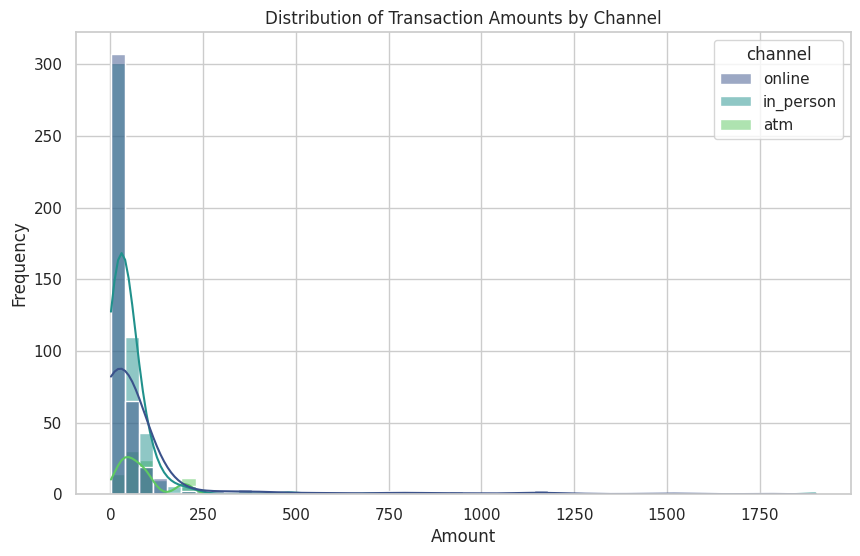

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Distribution of Transaction Amounts by Channel
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='amount', hue='channel', kde=True, bins=50, palette='viridis')
plt.title('Distribution of Transaction Amounts by Channel')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1035/2725968380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mismatch_counts, x='Metric', y='Count', palette='magma')


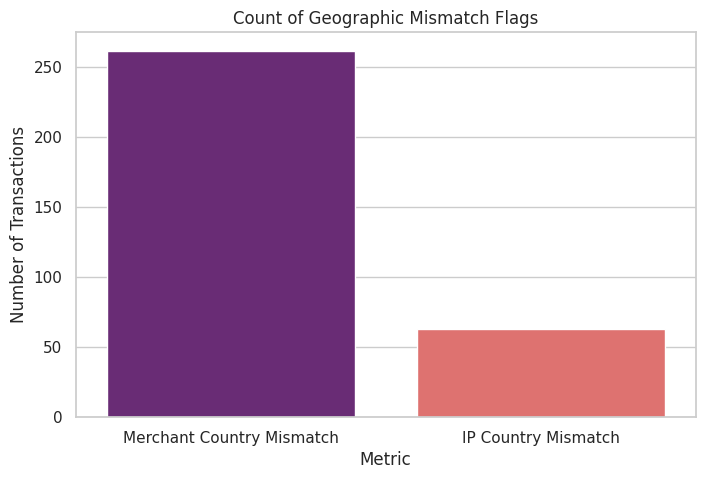

In [ ]:
# 2. Analyzing Country Mismatches and IP Mismatches
mismatch_counts = pd.DataFrame({
    'Metric': ['Merchant Country Mismatch', 'IP Country Mismatch'],
    'Count': [df['country_mismatch'].sum(), df['ip_mismatch'].sum()]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=mismatch_counts, x='Metric', y='Count', palette='magma')
plt.title('Count of Geographic Mismatch Flags')
plt.ylabel('Number of Transactions')
plt.show()

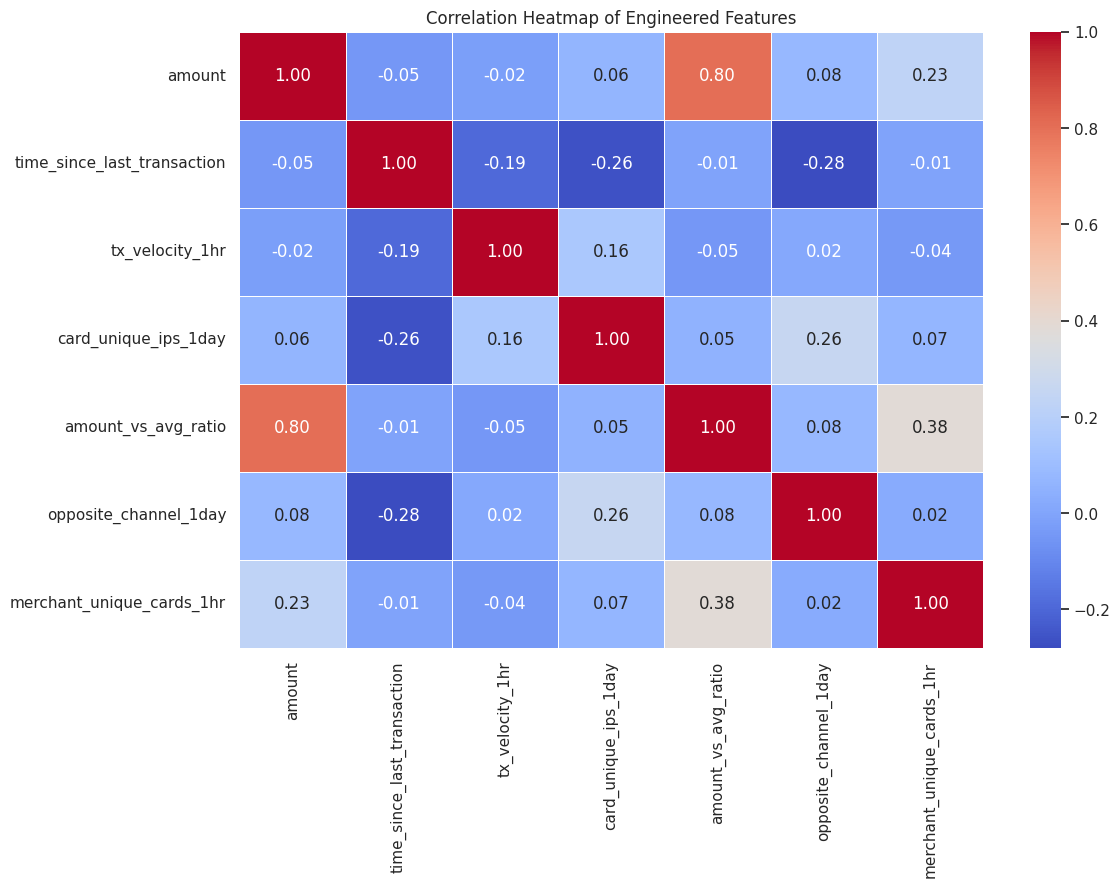

In [ ]:
# 3. Correlation Heatmap of Numeric Features
# Selecting a subset of engineered features for clarity
features_to_corr = [
    'amount', 'time_since_last_transaction', 'tx_velocity_1hr',
    'card_unique_ips_1day', 'amount_vs_avg_ratio', 'opposite_channel_1day',
    'merchant_unique_cards_1hr'
]

corr_matrix = df[features_to_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Engineered Features')
plt.show()

/tmp/ipykernel_1035/1826442085.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_preferred_category', y='amount', palette='Set2')


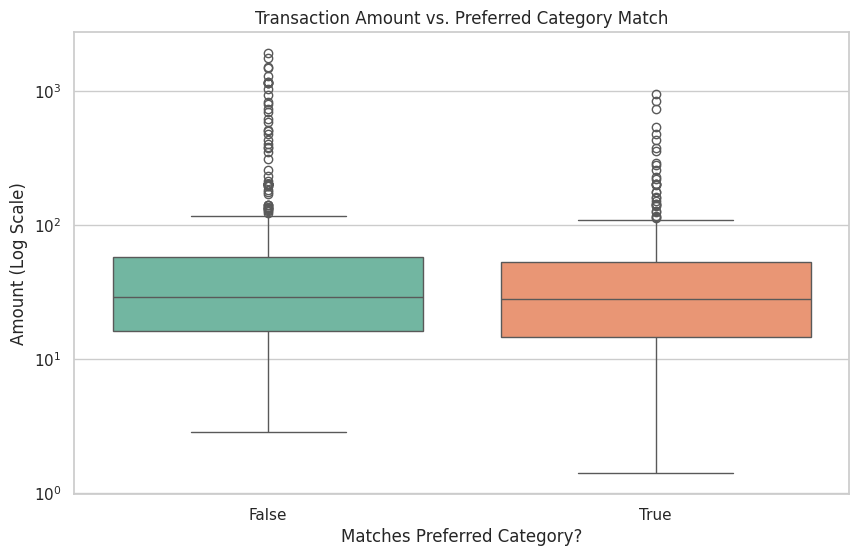

In [ ]:
# 4. Boxplot of Amount vs. Preferred Category Flag
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_preferred_category', y='amount', palette='Set2')
plt.yscale('log') # Using log scale due to potential outliers in amount
plt.title('Transaction Amount vs. Preferred Category Match')
plt.xlabel('Matches Preferred Category?')
plt.ylabel('Amount (Log Scale)')
plt.show()

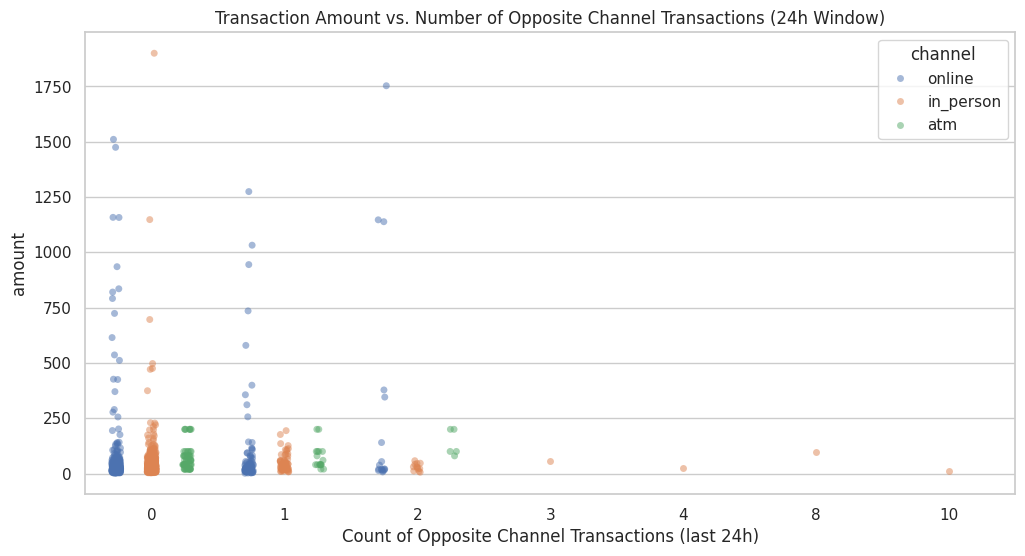

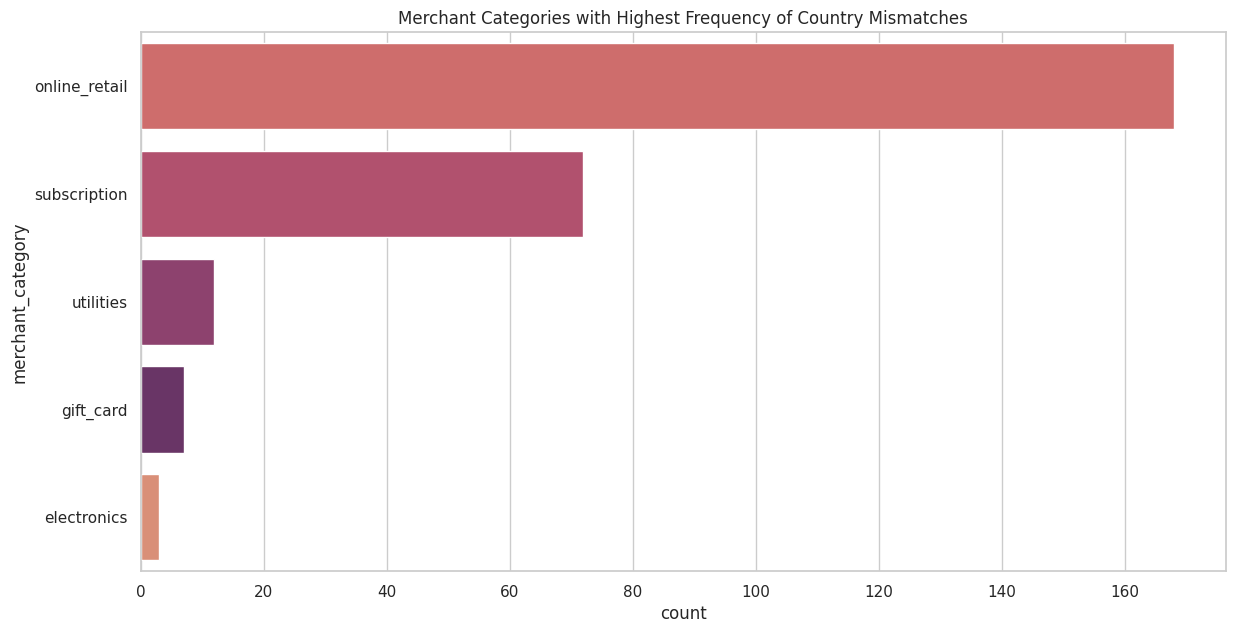

In [ ]:
# 5. High-Risk Signal Deep Dive: Opposite Channel Activity
plt.figure(figsize=(12, 6))
sns.stripplot(data=df, x='opposite_channel_1day', y='amount', hue='channel', dodge=True, alpha=0.5)
plt.title('Transaction Amount vs. Number of Opposite Channel Transactions (24h Window)')
plt.xlabel('Count of Opposite Channel Transactions (last 24h)')
plt.show()

# 6. Merchant Category Analysis for Geography Mismatches
plt.figure(figsize=(14, 7))
mismatch_df = df[df['country_mismatch'] == True]
sns.countplot(data=mismatch_df, y='merchant_category', order=mismatch_df['merchant_category'].value_counts().index, hue='merchant_category', palette='flare', legend=False)
plt.title('Merchant Categories with Highest Frequency of Country Mismatches')
plt.show()

## Modeling


### Preprocessing

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from scipy.stats import rankdata

In [ ]:
pip install pyod kneed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 12.3 MB/s eta 0:00:00


In [ ]:
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.hbos import HBOS

from kneed import KneeLocator

In [ ]:
df.columns

Index(['transaction_id', 'timestamp', 'card_id', 'amount', 'merchant_name',
       'merchant_category', 'channel', 'cardholder_country',
       'merchant_country', 'device_id', 'ip_address', 'ip_country',
       'country_mismatch', 'ip_mismatch', 'time_since_last_transaction',
       'is_first_transaction', 'unique_cards_on_ip',
       'ip_shared_with_multiple_cards', 'unique_cards_on_device',
       'device_shared_with_multiple_cards', 'card_unique_ips_30min',
       'card_unique_ips_60min', 'card_unique_ips_12hr', 'card_unique_ips_1day',
       'card_unique_ip_countries_30min',
       'card_unique_merchant_countries_30min',
       'card_unique_ip_countries_60min',
       'card_unique_merchant_countries_60min', 'card_unique_ip_countries_12hr',
       'card_unique_merchant_countries_12hr', 'card_unique_ip_countries_1day',
       'card_unique_merchant_countries_1day', 'tx_velocity_30min',
       'tx_velocity_1hr', 'tx_velocity_1day', 'hour_of_day',
       'card_avg_transaction_amount', 

In [ ]:
# Complete list of all relevant engineered features for anomaly detection
model_features = [
    # Core metrics
    'amount', 'time_since_last_transaction', 'amount_vs_avg_ratio', 'card_avg_transaction_amount',
    # Transaction Velocity
    'tx_velocity_30min', 'tx_velocity_1hr', 'tx_velocity_1day',
    # IP & Country Diversity (Rolling Windows)
    'card_unique_ips_30min', 'card_unique_ips_60min', 'card_unique_ips_12hr', 'card_unique_ips_1day',
    'card_unique_ip_countries_30min', 'card_unique_ip_countries_60min', 'card_unique_ip_countries_12hr', 'card_unique_ip_countries_1day',
    'card_unique_merchant_countries_30min', 'card_unique_merchant_countries_60min', 'card_unique_merchant_countries_12hr', 'card_unique_merchant_countries_1day',
    # Behavioral Patterns
    'opposite_channel_30min', 'opposite_channel_60min', 'opposite_channel_12hr', 'opposite_channel_1day',
    'merchant_unique_cards_1hr', 'total_tx_count_per_card', 'unique_merchants_per_card',
    # Flags and Temporal
    'hour_of_day', 'country_mismatch', 'ip_mismatch', 'is_impossible_travel',
    'is_preferred_category', 'ip_shared_with_multiple_cards', 'is_first_transaction'
]

# Prepare feature matrix X
X = df[model_features].copy()

# Convert boolean flags to integers (0/1)
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

# Fill remaining NaNs using the median (more robust than filling with zero)
# This is consistent with our use of RobustScaler
X = X.fillna(X.median())

# Apply RobustScaler to the full feature set
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for verification
X_scaled_df = pd.DataFrame(X_scaled, columns=model_features, index=df.index)

print(f"Scaled {len(model_features)} features using RobustScaler with Median Imputation.")
display(X_scaled_df.head())

Scaled 33 features using RobustScaler with Median Imputation.


,amount,time_since_last_transaction,amount_vs_avg_ratio,card_avg_transaction_amount,tx_velocity_30min,tx_velocity_1hr,tx_velocity_1day,card_unique_ips_30min,card_unique_ips_60min,card_unique_ips_12hr,...,merchant_unique_cards_1hr,total_tx_count_per_card,unique_merchants_per_card,hour_of_day,country_mismatch,ip_mismatch,is_impossible_travel,is_preferred_category,ip_shared_with_multiple_cards,is_first_transaction
0,0.571677,0.000000,-0.075730,0.893992,0.0,0.0,-0.5,1.0,1.0,1.0,...,0.0,0.0,0.0,0.230769,0.0,0.0,0.0,1.0,0.0,1.0
1,1.352273,1.872465,0.319542,0.893992,0.0,0.0,-0.5,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.153846,0.0,0.0,0.0,0.0,0.0,0.0
2,2.158179,3.571033,0.727631,0.893992,0.0,0.0,-0.5,1.0,1.0,1.0,...,0.0,0.0,0.0,0.538462,0.0,0.0,0.0,1.0,0.0,0.0
3,0.158799,-0.002783,-0.284800,0.893992,0.0,0.0,0.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.384615,0.0,0.0,0.0,0.0,0.0,0.0
4,24.912102,-0.603336,12.249592,0.893992,1.0,1.0,1.5,1.0,1.0,1.0,...,0.0,0.0,0.0,0.461538,1.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
detectors = {
    'iforest': IForest(
        contamination=0.07,
        n_estimators=200,
        random_state=42
    ),
    'ecod': ECOD(
        contamination=0.07
    ),
    'copod': COPOD(
        contamination=0.07
    ),
    'hbos': HBOS(
        contamination=0.07,
        n_bins='auto'
    ),
}

raw_scores = {}
binary_labels = {}

for name, det in detectors.items():
    det.fit(X_scaled)
    raw_scores[name] = det.decision_scores_   # continuous anomaly score
    binary_labels[name] = det.labels_         # 0/1 at contamination threshold
    print(f"{name}: flagged {det.labels_.sum()} transactions as fraud")

iforest: flagged 70 transactions as fraud
ecod: flagged 70 transactions as fraud
copod: flagged 70 transactions as fraud
hbos: flagged 70 transactions as fraud


In [ ]:
labels_df = pd.DataFrame(binary_labels)

# agreement matrix — how often do pairs agree?
print(labels_df.corr())

# how many flagged by all 4 vs just 1?
labels_df['votes'] = labels_df.sum(axis=1)
print(labels_df['votes'].value_counts().sort_index())

          iforest      ecod     copod      hbos
iforest  1.000000  0.831029  0.846390  0.692780
ecod     0.831029  1.000000  0.953917  0.815668
copod    0.846390  0.953917  1.000000  0.800307
hbos     0.692780  0.815668  0.800307  1.000000
votes
0    909
1     17
2      6
3     21
4     47
Name: count, dtype: int64


In [ ]:
# rank normalize each detector's scores then average
ranked_scores = np.column_stack([
    rankdata(raw_scores[name]) for name in detectors.keys()
])
ensemble_score = ranked_scores.mean(axis=1)

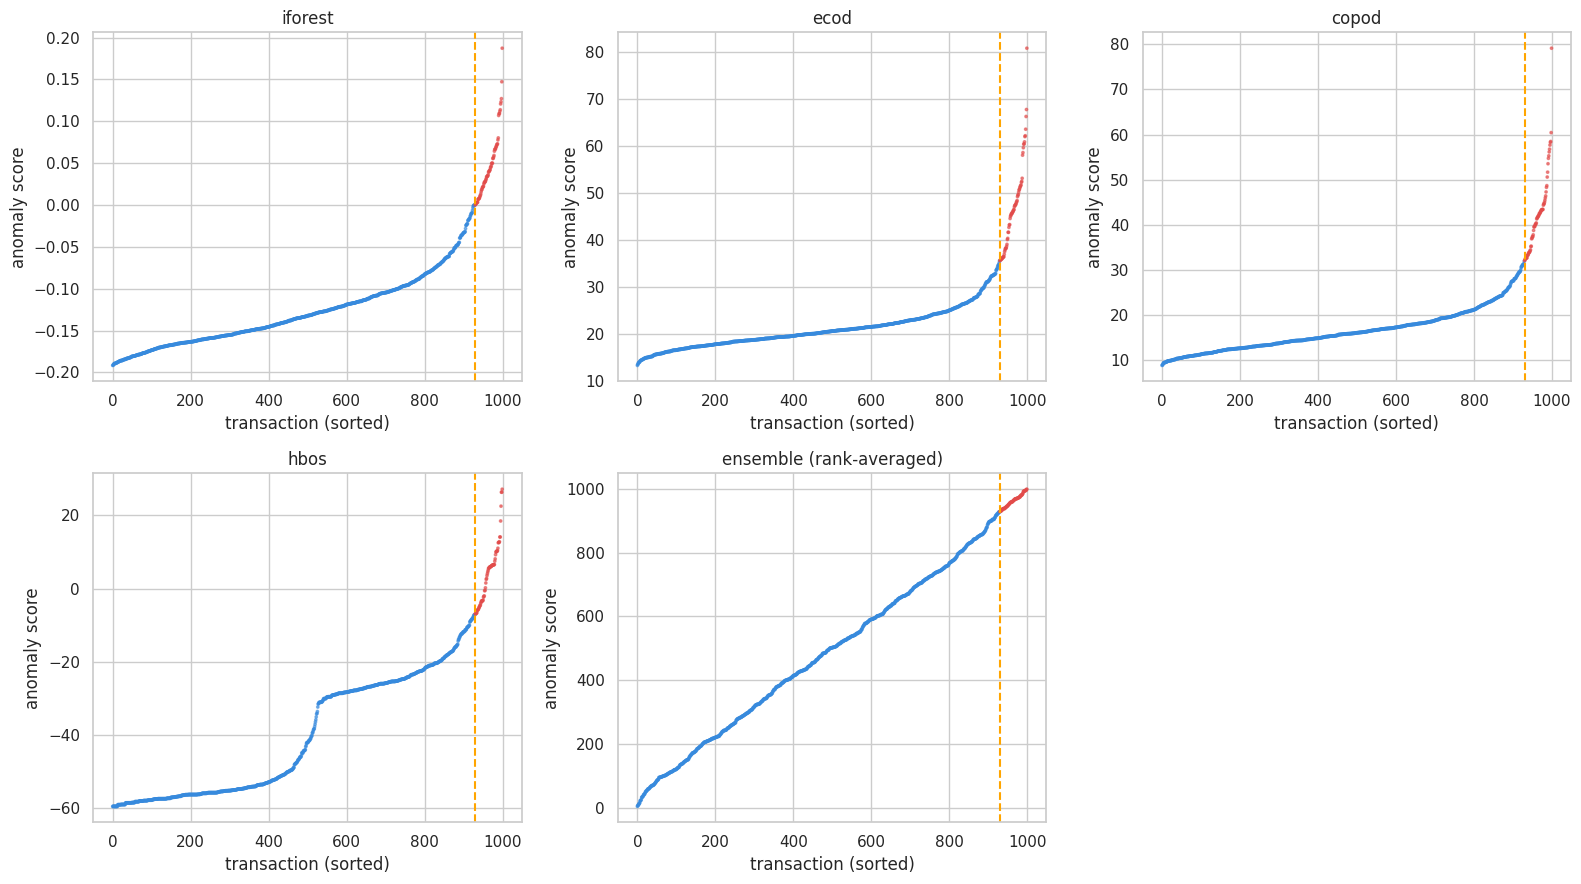

In [ ]:
# add back to dataframe for inspection
df['anomaly_score'] = ensemble_score
df['votes'] = labels_df['votes'].values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, name in enumerate(detectors.keys()):
    sorted_scores = np.sort(raw_scores[name])
    threshold_idx = int(len(sorted_scores) * 0.93)
    colors = ['#E24B4A' if j >= threshold_idx else '#378ADD'
              for j in range(len(sorted_scores))]
    axes[i].scatter(range(len(sorted_scores)), sorted_scores,
                    c=colors, s=3, alpha=0.6)
    axes[i].axvline(x=threshold_idx, color='orange',
                    linestyle='--', linewidth=1.5)
    axes[i].set_title(name)
    axes[i].set_xlabel('transaction (sorted)')
    axes[i].set_ylabel('anomaly score')

# ensemble plot
sorted_ens = np.sort(ensemble_score)
threshold_idx = int(len(sorted_ens) * 0.93)
colors_ens = ['#E24B4A' if j >= threshold_idx else '#378ADD'
              for j in range(len(sorted_ens))]
axes[4].scatter(range(len(sorted_ens)), sorted_ens,
                c=colors_ens, s=3, alpha=0.6)
axes[4].axvline(x=threshold_idx, color='orange', linestyle='--', linewidth=1.5)
axes[4].set_title('ensemble (rank-averaged)')
axes[4].set_xlabel('transaction (sorted)')
axes[4].set_ylabel('anomaly score')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('elbow_plots.png', dpi=150)
plt.show()

In [ ]:
# Map votes to confidence labels
confidence_mapping = {
    0: 'normal',
    1: 'ignore',
    2: 'low confidence',
    3: 'medium confidence',
    4: 'high confidence'
}

# Calculate counts
vote_summary = df['votes'].value_counts().sort_index().reset_index()
vote_summary.columns = ['Votes', 'Count']
vote_summary['Label'] = vote_summary['Votes'].map(confidence_mapping)

# Reorder and display
vote_summary = vote_summary[['Votes', 'Count', 'Label']]
print("Anomaly Detection Consensus Summary:")
display(vote_summary)

# Add labels to the main dataframe for easier filtering later
df['fraud_confidence'] = df['votes'].map(confidence_mapping)

Anomaly Detection Consensus Summary:


,Votes,Count,Label
0,0,909,normal
1,1,17,ignore
2,2,6,low confidence
3,3,21,medium confidence
4,4,47,high confidence


In [ ]:
# Define binary fraud label based on threshold (3 or more votes)
df['is_fraud'] = (df['votes'] >= 3).astype(int)

fraud_count = df['is_fraud'].sum()
total_tx = len(df)
fraud_rate = (fraud_count / total_tx) * 100

print(f"Total transactions: {total_tx}")
print(f"Transactions flagged as fraud (votes >= 3): {fraud_count}")
print(f"Final implied fraud rate: {fraud_rate:.2f}%")

# Display a sample of the identified fraud cases
display(df[df['is_fraud'] == 1][['transaction_id', 'card_id', 'amount', 'merchant_category', 'votes', 'fraud_confidence']].head(10))

Total transactions: 1000
Transactions flagged as fraud (votes >= 3): 68
Final implied fraud rate: 6.80%


,transaction_id,card_id,amount,merchant_category,votes,fraud_confidence
4,tx_000983,card_000,1032.48,electronics,4,high confidence
112,tx_000113,card_006,13.99,subscription,4,high confidence
163,tx_000152,card_008,41.73,online_retail,4,high confidence
166,tx_000150,card_008,15.28,online_retail,3,medium confidence
240,tx_000242,card_012,30.52,grocery,4,high confidence
283,tx_000284,card_015,58.27,utilities,3,medium confidence
309,tx_000987,card_016,1511.01,gift_card,3,medium confidence
351,tx_000992,card_018,1753.33,gift_card,3,medium confidence
352,tx_000994,card_018,1147.16,gift_card,3,medium confidence
353,tx_000993,card_018,1138.68,gift_card,4,high confidence


## Results

In [ ]:
import shap

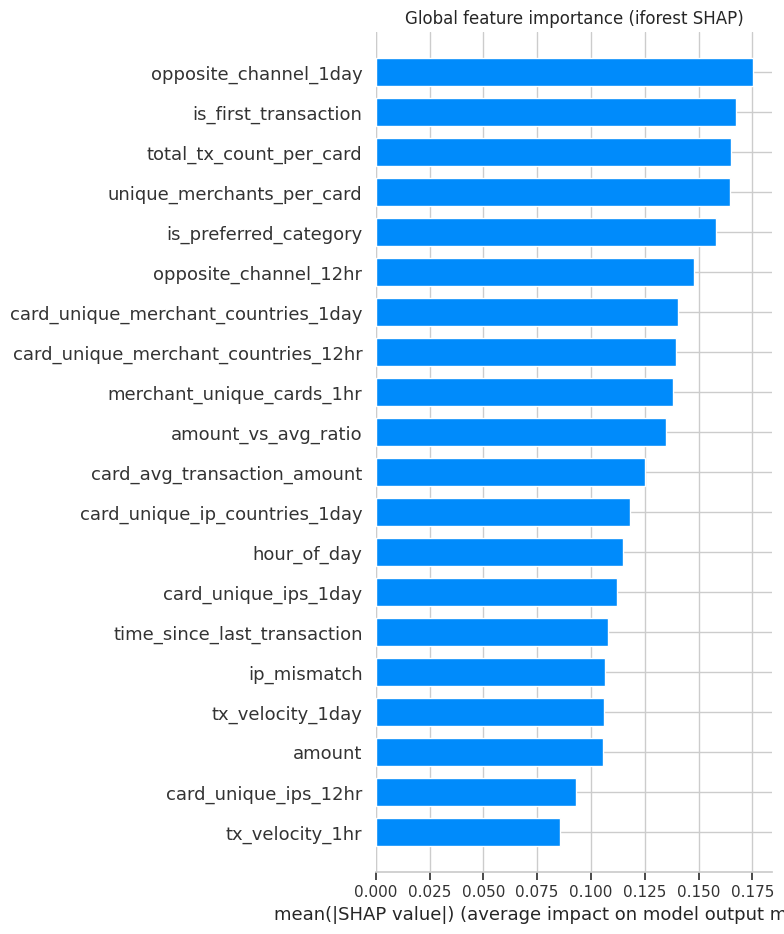

In [ ]:
explainer = shap.TreeExplainer(detectors['iforest'].detector_)
shap_values = explainer.shap_values(X_scaled)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_scaled_df,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Global feature importance (iforest SHAP)')
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150)
plt.show()

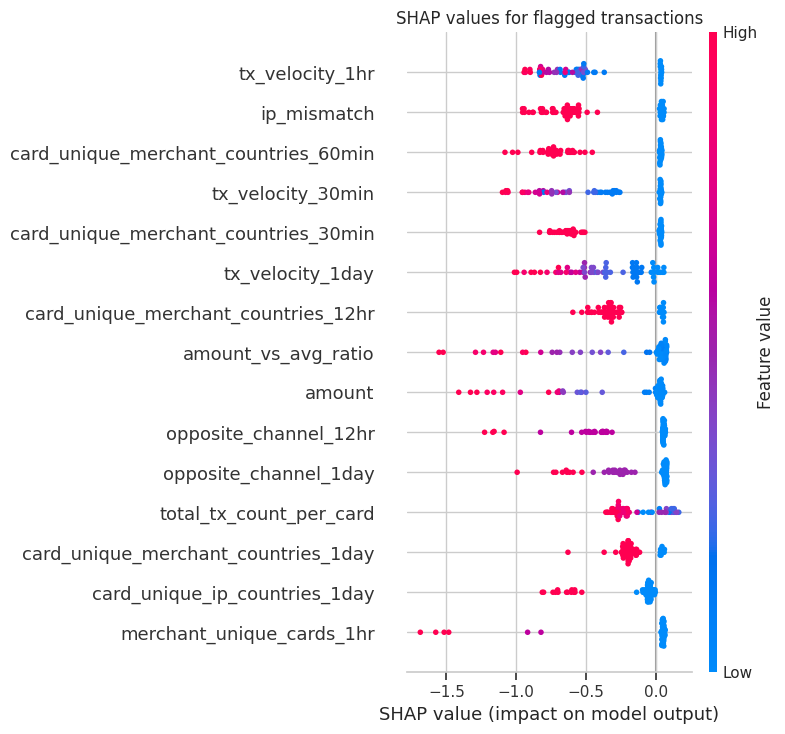

In [ ]:
plt.figure(figsize=(10, 8))
# Use 'fraud_confidence' as defined in the previous steps
fraud_mask = df['fraud_confidence'].isin(['high confidence', 'medium confidence'])

shap.summary_plot(
    shap_values[fraud_mask],
    X_scaled_df[fraud_mask],
    max_display=15,
    show=False
)
plt.title('SHAP values for flagged transactions')
plt.tight_layout()
plt.savefig('shap_fraud_beeswarm.png', dpi=150)
plt.show()

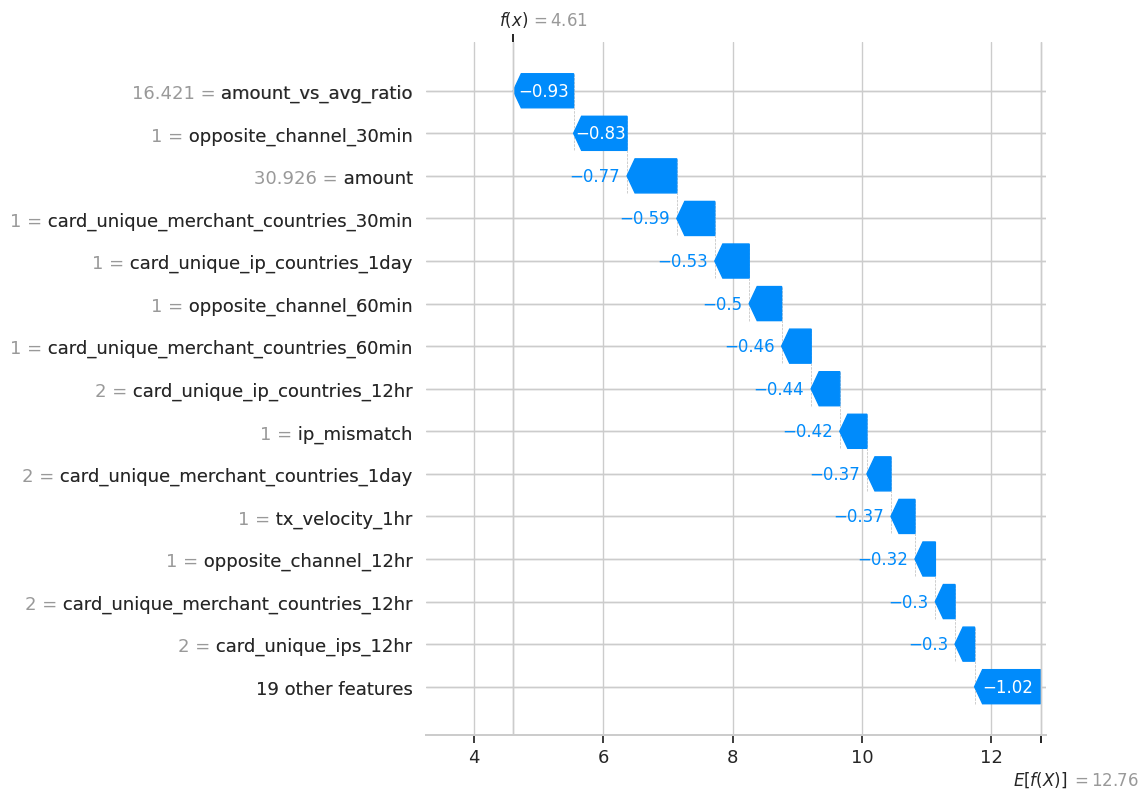

In [ ]:
top_fraud_idx = (df[df['fraud_confidence'] == 'high confidence']
    .sort_values('anomaly_score', ascending=False)
    .index[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[top_fraud_idx],
        base_values=explainer.expected_value,
        data=X_scaled_df.iloc[top_fraud_idx],
        feature_names=model_features
    ),
    max_display=15,
    show=True
)

In [ ]:

import joblib, os

ARTIFACTS_DIR = "../backend/app/models/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Save each fitted detector
for name, det in detectors.items():
    joblib.dump(det, f"{ARTIFACTS_DIR}/{name}.joblib")
    print(f"Saved {name}.joblib")

# Save the fitted RobustScaler
joblib.dump(scaler, f"{ARTIFACTS_DIR}/scaler.joblib")
print("Saved scaler.joblib")

# Save the ordered feature list (order matters for inference)
joblib.dump(model_features, f"{ARTIFACTS_DIR}/feature_columns.joblib")
print("Saved feature_columns.joblib")

print(f"\nAll artifacts saved to {ARTIFACTS_DIR}/")
print(f"Contents: {sorted(os.listdir(ARTIFACTS_DIR))}")


A FAIRE

import anthropic

client = anthropic.Anthropic(api_key="YOUR_KEY")

def explain_fraud_case(row_idx, shap_vals, top_n=5):
    # get top N features driving this prediction
    feat_importance = sorted(
        zip(model_features, shap_vals[row_idx]),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:top_n]
    
    # get actual feature values for this row
    row_data = df.iloc[row_idx]
    
    # build context for LLM
    feature_context = "\n".join([
        f"- {feat}: value={X_scaled_df.iloc[row_idx][feat]:.2f}, "
        f"SHAP contribution={contrib:+.4f} ({'increases' if contrib > 0 else 'decreases'} fraud score)"
        for feat, contrib in feat_importance
    ])
    
    prompt = f"""
A transaction has been flagged as high-confidence fraud by 4 independent
anomaly detection models. Here are the top features driving this decision:

{feature_context}

Transaction details:
- Amount: {row_data.get('amount', 'N/A')}
- Hour of day: {row_data.get('hour_of_day', 'N/A')}
- Confidence level: {row_data.get('confidence', 'N/A')}
- Anomaly score: {row_data.get('anomaly_score', 'N/A'):.1f}/1000

In 2-3 sentences, explain why this transaction is suspicious in plain English
for a fraud analyst. Be specific about which signals are most concerning.
"""
    
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=200,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text

# run on top 5 highest confidence cases
top_5_idx = (df[df['confidence'] == 'high']
    .sort_values('anomaly_score', ascending=False)
    .head(5)
    .index)

for idx in top_5_idx:
    print(f"\nTransaction {idx} (score: {df.loc[idx, 'anomaly_score']:.1f})")
    print(explain_fraud_case(idx, shap_values))
    print("-" * 60)